In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [36]:
DATA_PATH = Path("../data/processed/dataset_solar_2023_2024_v3.parquet")

df = pd.read_parquet(DATA_PATH)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 1,052,640
Columnas: 27


,ano,mes_sin,mes_cos,dia,hora_sin,hora_cos,minuto,fecha,ghi,dni,dhi,ghi_estimado,irr_null,error_balance,error_balance_abs,error_balance_rel,elevacion_solar,periodo_solar,temperatura,velocidad_viento,humedad_relativa,direccion_viento_sin,direccion_viento_cos,var_meteo_imp,codigo_ghi,codigo_dni,codigo_dhi
0,2023,0.0000,1.0000,1,0.0000,1.0000,0,2023-01-01 00:00:00,0.0000,0.0000,0.0000,0.0000,False,0.0000,0.0000,0.0000,-74.4853,noche,10.0000,1.0500,77.0000,0.8850,-0.4656,False,0,0,0
1,2023,0.0000,1.0000,1,0.0000,1.0000,1,2023-01-01 00:01:00,0.0000,0.0000,0.0000,0.0000,False,0.0000,0.0000,0.0000,-74.5649,noche,10.0000,1.3330,77.0000,-0.7490,0.6626,False,0,0,0
2,2023,0.0000,1.0000,1,0.0000,1.0000,2,2023-01-01 00:02:00,0.0000,0.0000,0.0000,0.0000,False,0.0000,0.0000,0.0000,-74.6419,noche,10.0000,1.1000,77.0000,-0.9720,-0.2349,False,0,0,0
3,2023,0.0000,1.0000,1,0.0000,1.0000,3,2023-01-01 00:03:00,0.0000,0.0000,0.0000,0.0000,False,0.0000,0.0000,0.0000,-74.7163,noche,10.0000,1.3330,77.0000,-0.9372,0.3489,False,0,0,0
4,2023,0.0000,1.0000,1,0.0000,1.0000,4,2023-01-01 00:04:00,0.0000,0.0000,0.0000,0.0000,False,0.0000,0.0000,0.0000,-74.7881,noche,10.0000,1.0580,77.0000,-0.4436,0.8962,False,0,0,0


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1052640 entries, 0 to 1052639
Data columns (total 27 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   ano                   1052640 non-null  int64         
 1   mes_sin               1052640 non-null  float64       
 2   mes_cos               1052640 non-null  float64       
 3   dia                   1052640 non-null  int64         
 4   hora_sin              1052640 non-null  float64       
 5   hora_cos              1052640 non-null  float64       
 6   minuto                1052640 non-null  int64         
 7   fecha                 1052640 non-null  datetime64[us]
 8   ghi                   1040772 non-null  float64       
 9   dni                   1040772 non-null  float64       
 10  dhi                   1040772 non-null  float64       
 11  ghi_estimado          1040772 non-null  float64       
 12  irr_null              1052640 non-null  bool         

In [72]:
RANDOM_STATE = 42

TARGETS = [
    "codigo_ghi",
    "codigo_dni",
    "codigo_dhi",
]

In [39]:
def class_distribution(data, target):
    """
    Calcula la distribución absoluta y porcentual de las clases
    de una variable objetivo.
    """
    
    counts = (
        data[target]
        .value_counts(dropna=False)
        .sort_index()
    )

    percentages = (
        data[target]
        .value_counts(normalize=True, dropna=False)
        .sort_index()
        * 100
    )

    distribution = pd.DataFrame({
        "n_muestras": counts,
        "porcentaje": percentages
    })

    return distribution
    

In [40]:
for target in TARGETS:
    print(f"\nDistribución de {target}")
    display(class_distribution(df, target))


Distribución de codigo_ghi


,n_muestras,porcentaje
codigo_ghi,,
0,899970,85.4965
1,152670,14.5035



Distribución de codigo_dni


,n_muestras,porcentaje
codigo_dni,,
0,943668,89.6477
1,107047,10.1694
2,1925,0.1829



Distribución de codigo_dhi


,n_muestras,porcentaje
codigo_dhi,,
0,860006,81.6999
1,192246,18.2632
2,388,0.0369


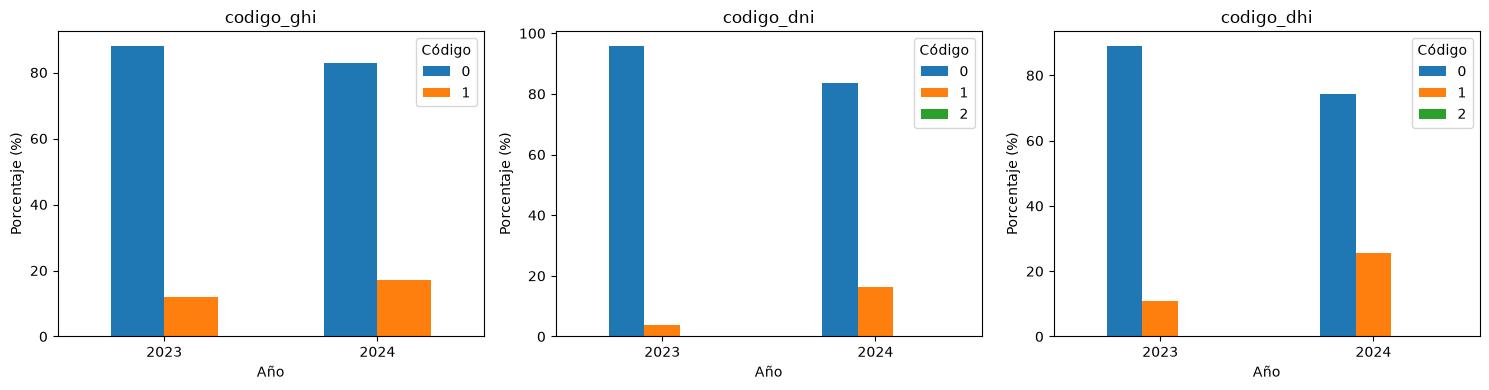

In [41]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4)
)

for ax, target in zip(axes, TARGETS):
    
    percentages = pd.crosstab(
        df["ano"],
        df[target],
        normalize="index"
    ) * 100

    percentages.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(target)
    ax.set_xlabel("Año")
    ax.set_ylabel("Porcentaje (%)")
    ax.legend(title="Código")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [42]:
EXCLUDED_COLUMNS = [
    "fecha",
    "ano",
]

In [43]:
candidate_columns = [
    col for col in df.columns
    if col not in EXCLUDED_COLUMNS
]

print(f"Columnas totales: {df.shape[1]}")
print(f"Columnas excluidas inicialmente: {len(EXCLUDED_COLUMNS)}")
print(f"Columnas a estudiar: {len(candidate_columns)}")

Columnas totales: 27
Columnas excluidas inicialmente: 2
Columnas a estudiar: 25


In [44]:
feature_analysis = pd.DataFrame({
    "variable": candidate_columns,
    "dtype": [str(df[col].dtype) for col in candidate_columns],
    "n_unique": [df[col].nunique(dropna=True) for col in candidate_columns],
    "n_null": [df[col].isna().sum() for col in candidate_columns],
    "pct_null": [df[col].isna().mean() * 100 for col in candidate_columns],
})

feature_analysis = feature_analysis.sort_values(
    ["pct_null", "variable"],
    ascending=[False, True]
).reset_index(drop=True)

display(feature_analysis)

,variable,dtype,n_unique,n_null,pct_null
0,direccion_viento_cos,float64,13599,94681,8.9946
1,direccion_viento_sin,float64,13053,94681,8.9946
2,velocidad_viento,float64,4533,94681,8.9946
3,humedad_relativa,float64,4011,94624,8.9892
4,temperatura,float64,15839,94624,8.9892
5,dhi,float64,25891,11868,1.1275
6,dni,float64,34272,11868,1.1275
7,error_balance,float64,471963,11868,1.1275
8,error_balance_abs,float64,471556,11868,1.1275
9,error_balance_rel,float64,479165,11868,1.1275


In [45]:
numeric_columns = [
    col for col in candidate_columns
    if pd.api.types.is_numeric_dtype(df[col])
    and not pd.api.types.is_bool_dtype(df[col])
]

categorical_columns = [
    col for col in candidate_columns
    if not pd.api.types.is_numeric_dtype(df[col])
    or pd.api.types.is_bool_dtype(df[col])
]

print(f"Variables numéricas: {len(numeric_columns)}")
print(numeric_columns)

print(f"\nVariables categóricas: {len(categorical_columns)}")
print(categorical_columns)

Variables numéricas: 22
['mes_sin', 'mes_cos', 'dia', 'hora_sin', 'hora_cos', 'minuto', 'ghi', 'dni', 'dhi', 'ghi_estimado', 'error_balance', 'error_balance_abs', 'error_balance_rel', 'elevacion_solar', 'temperatura', 'velocidad_viento', 'humedad_relativa', 'direccion_viento_sin', 'direccion_viento_cos', 'codigo_ghi', 'codigo_dni', 'codigo_dhi']

Variables categóricas: 3
['irr_null', 'periodo_solar', 'var_meteo_imp']


In [46]:
df["periodo_solar"] = df["periodo_solar"].replace({
    "noche": 0,
    "dia": 1
})

df["var_meteo_imp"] = df["var_meteo_imp"].astype(int)

df["irr_null"] = df["irr_null"].astype(int)

In [47]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
mes_sin,1052640.0000,-0.0028,0.7069,-1.0000,-0.5000,0.0000,0.8660,1.0000
mes_cos,1052640.0000,-0.0036,0.7073,-1.0000,-0.8660,-0.0000,0.5000,1.0000
dia,1052640.0000,15.7387,8.8039,1.0000,8.0000,16.0000,23.0000,31.0000
hora_sin,1052640.0000,0.0000,0.7071,-1.0000,-0.7071,0.0000,0.7071,1.0000
hora_cos,1052640.0000,-0.0000,0.7071,-1.0000,-0.7071,-0.0000,0.7071,1.0000
minuto,1052640.0000,29.5000,17.3181,0.0000,14.7500,29.5000,44.2500,59.0000
ghi,1040772.0000,178.2728,285.5770,0.0000,0.0000,0.0000,293.8000,2525.5000
dni,1040772.0000,228.8883,341.5533,0.0000,0.0000,0.0000,537.9170,1083.2500
dhi,1040772.0000,70.1529,135.6085,0.0000,0.0000,0.0000,80.6360,1153.0000
ghi_estimado,1040772.0000,205.8388,323.6677,0.0000,0.0000,0.0000,346.5590,1940.7440


In [48]:
for col in categorical_columns:
    print(f"\n--- {col} ---")

    distribution = pd.DataFrame({
        "n_muestras": df[col].value_counts(dropna=False),
        "porcentaje": (
            df[col]
            .value_counts(normalize=True, dropna=False)
            * 100
        )
    })

    display(distribution)


--- irr_null ---


,n_muestras,porcentaje
irr_null,,
0,1040772,98.8725
1,11868,1.1275



--- periodo_solar ---


,n_muestras,porcentaje
periodo_solar,,
1,532532,50.5901
0,520108,49.4099



--- var_meteo_imp ---


,n_muestras,porcentaje
var_meteo_imp,,
0,1051943,99.9338
1,697,0.0662


In [49]:
FEATURE_GROUPS = {
    
    "temporales": [
        "mes_sin",
        "mes_cos",
        "dia",
        "hora_sin",
        "hora_cos",
        "minuto",
    ],
    
    "irradiancia": [
        "ghi",
        "dni",
        "dhi",
        "ghi_estimado",
    ],
    
    "balance_irradiancia": [
        "error_balance",
        "error_balance_abs",
        "error_balance_rel",
    ],
    
    "solar": [
        "elevacion_solar",
        "periodo_solar",
    ],
    
    "meteorologicas": [
        "temperatura",
        "velocidad_viento",
        "humedad_relativa",
        "direccion_viento_sin",
        "direccion_viento_cos",
    ],
    
    "calidad_datos": [
        "irr_null",
        "var_meteo_imp",
    ],
    
    "targets": [
        "codigo_ghi",
        "codigo_dni",
        "codigo_dhi",
    ],
}

In [50]:
feature_groups_df = pd.DataFrame([
    {
        "variable": variable,
        "grupo": group
    }
    for group, variables in FEATURE_GROUPS.items()
    for variable in variables
])

feature_groups_df = feature_groups_df.merge(
    feature_analysis,
    on="variable",
    how="left"
)

display(feature_groups_df)

,variable,grupo,dtype,n_unique,n_null,pct_null
0,mes_sin,temporales,float64,11,0,0.0000
1,mes_cos,temporales,float64,11,0,0.0000
2,dia,temporales,int64,31,0,0.0000
3,hora_sin,temporales,float64,21,0,0.0000
4,hora_cos,temporales,float64,22,0,0.0000
5,minuto,temporales,int64,60,0,0.0000
6,ghi,irradiancia,float64,38878,11868,1.1275
7,dni,irradiancia,float64,34272,11868,1.1275
8,dhi,irradiancia,float64,25891,11868,1.1275
9,ghi_estimado,irradiancia,float64,473018,11868,1.1275


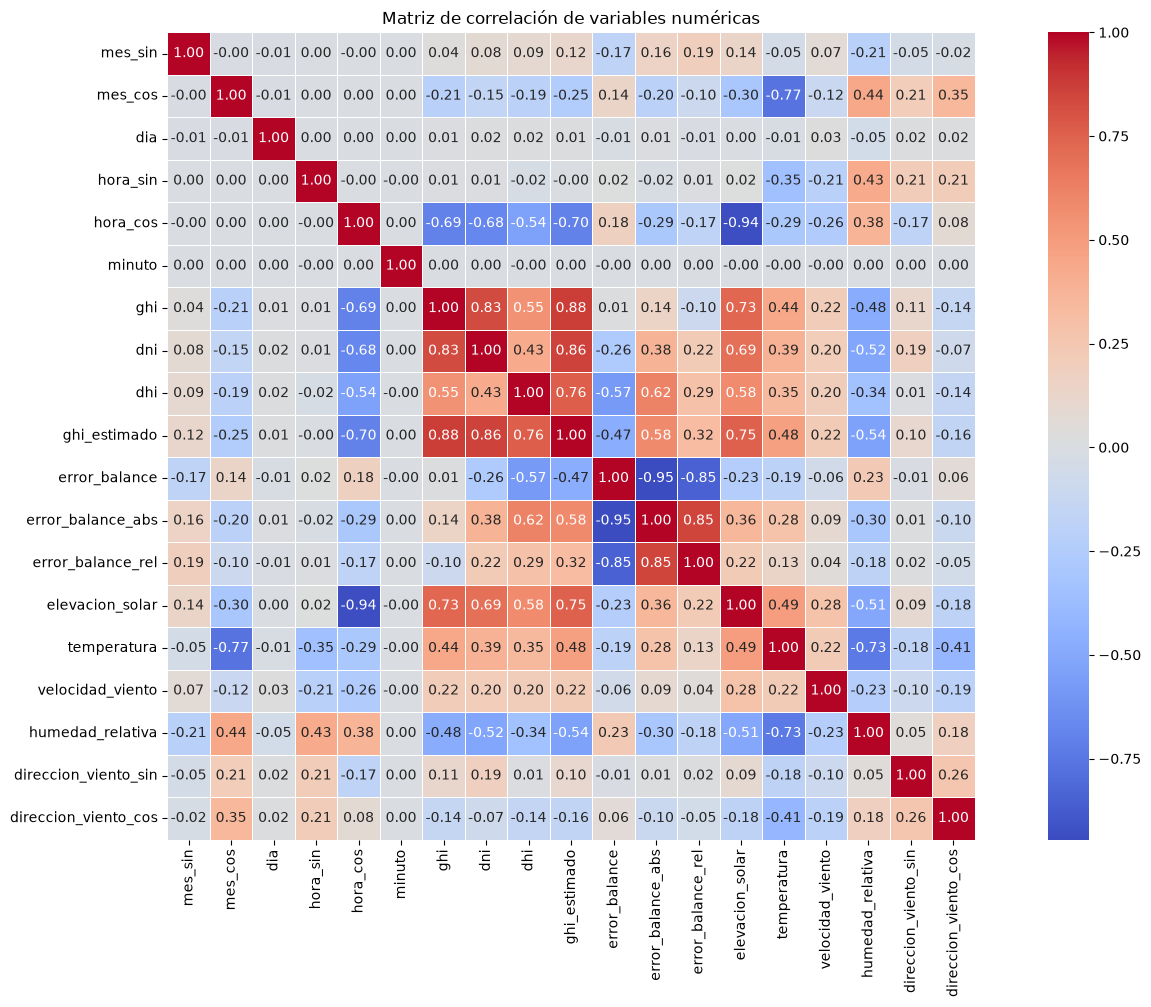

In [51]:
corr_matrix = df[
    [
        col
        for col in numeric_columns
        if col not in [
            "codigo_ghi",
            "codigo_dni",
            "codigo_dhi",
        ]
    ]
].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5
)
plt.tight_layout()
plt.title("Matriz de correlación de variables numéricas")
plt.show()

In [52]:
feature_audit = feature_groups_df[
    ["variable", "grupo", "dtype", "n_unique", "n_null", "pct_null"]
].copy()

feature_audit["decision"] = "usar"
feature_audit["motivo"] = ""

display(feature_audit)

,variable,grupo,dtype,n_unique,n_null,pct_null,decision,motivo
0,mes_sin,temporales,float64,11,0,0.0000,usar,
1,mes_cos,temporales,float64,11,0,0.0000,usar,
2,dia,temporales,int64,31,0,0.0000,usar,
3,hora_sin,temporales,float64,21,0,0.0000,usar,
4,hora_cos,temporales,float64,22,0,0.0000,usar,
5,minuto,temporales,int64,60,0,0.0000,usar,
6,ghi,irradiancia,float64,38878,11868,1.1275,usar,
7,dni,irradiancia,float64,34272,11868,1.1275,usar,
8,dhi,irradiancia,float64,25891,11868,1.1275,usar,
9,ghi_estimado,irradiancia,float64,473018,11868,1.1275,usar,


In [53]:
EXCLUDE_ALWAYS = {
    "fecha": "Identificador temporal; no se utiliza directamente como predictor.",
    "ano": "Se utiliza para definir la separación temporal train/test.",
}

TARGET_COLUMNS = {
    "codigo_ghi": "Variable objetivo.",
    "codigo_dni": "Variable objetivo.",
    "codigo_dhi": "Variable objetivo.",
}

In [54]:
group_motives = {
    "irradiancia": (
        "Variables principales sobre las que se evalúa la calidad de las medidas. "
        "Sus valores y relaciones permiten detectar comportamientos anómalos o incoherentes."
    ),

    "meteorologicas": (
        "Las condiciones meteorológicas pueden influir en las medidas de irradiancia "
        "y ayudar a contextualizar su comportamiento. Presentan valores nulos, por lo que "
        "su utilidad dependerá de la capacidad de cada modelo para manejarlos o del "
        "preprocesamiento aplicado."
    ),

    "solar": (
        "Variables que describen la posición o condición solar y permiten contextualizar "
        "físicamente las medidas de irradiancia según la situación del Sol."
    ),

    "temporales": (
        "Permiten capturar patrones temporales y estacionales en las medidas y en la aparición "
        "de posibles errores de calidad a lo largo del día, mes y año."
    ),

    "calidad_datos": (
        "Variables que aportan información sobre la calidad o procedencia de los datos "
        "tras el proceso de preprocesamiento e imputación."
    ),
}

In [55]:
for group, motive in group_motives.items():
    mask = (
        (feature_audit["grupo"] == group)
        & (feature_audit["motivo"] == "")
    )

    feature_audit.loc[mask, "motivo"] = motive

In [56]:
audit_decisions = {
    "ghi_estimado": {
        "decision": "excluir",
        "motivo": (
            "Variable intermedia utilizada para construir el error de balance; "
            "su información queda representada por error_balance_abs."
        ),
    },

    "error_balance": {
        "decision": "excluir",
        "motivo": (
            "Error firmado del balance. Para este problema interesa principalmente "
            "la magnitud de la discrepancia."
        ),
    },

    "error_balance_abs": {
        "decision": "usar",
        "motivo": (
            "Cuantifica directamente la magnitud de la incoherencia física "
            "entre la GHI medida y la reconstruida."
        ),
    },

    "error_balance_rel": {
        "decision": "excluir",
        "motivo": (
            "Representación adicional del mismo fenómeno; se excluye inicialmente "
            "para reducir redundancia."
        ),
    },

    "periodo_solar": {
        "decision": "usar",
        "motivo": (
            "Distingue explícitamente entre condiciones diurnas y nocturnas, "
            "relevantes para interpretar las medidas de irradiancia."
        ),
    },

    "var_meteo_imp": {
        "decision": "usar",
        "motivo": (
            "Aporta información sobre qué variables meteorológicas han sido "
            "imputadas y, por tanto, sobre la calidad/procedencia del dato."
        ),
    },

    "irr_null": {
        "decision": "usar",
        "motivo": (
            "Conserva información sobre la ausencia original de datos de irradiancia."
        ),
    },
}

In [57]:
for variable, info in audit_decisions.items():
    mask = feature_audit["variable"] == variable

    feature_audit.loc[mask, "decision"] = info["decision"]
    feature_audit.loc[mask, "motivo"] = info["motivo"]

In [58]:
for target, reason in TARGET_COLUMNS.items():
    mask = feature_audit["variable"] == target

    feature_audit.loc[mask, "decision"] = "excluir"
    feature_audit.loc[mask, "motivo"] = reason

In [59]:
display(
    feature_audit.sort_values(
        ["decision", "grupo", "variable"]
    ).reset_index(drop=True)
)

,variable,grupo,dtype,n_unique,n_null,pct_null,decision,motivo
0,error_balance,balance_irradiancia,float64,471963,11868,1.1275,excluir,Error firmado del balance. Para este problema ...
1,error_balance_rel,balance_irradiancia,float64,479165,11868,1.1275,excluir,Representación adicional del mismo fenómeno; s...
2,ghi_estimado,irradiancia,float64,473018,11868,1.1275,excluir,Variable intermedia utilizada para construir e...
3,codigo_dhi,targets,int64,3,0,0.0000,excluir,Variable objetivo.
4,codigo_dni,targets,int64,3,0,0.0000,excluir,Variable objetivo.
5,codigo_ghi,targets,int64,2,0,0.0000,excluir,Variable objetivo.
6,error_balance_abs,balance_irradiancia,float64,471556,11868,1.1275,usar,Cuantifica directamente la magnitud de la inco...
7,irr_null,calidad_datos,bool,2,0,0.0000,usar,Conserva información sobre la ausencia origina...
8,var_meteo_imp,calidad_datos,bool,2,0,0.0000,usar,Aporta información sobre qué variables meteoro...
9,dhi,irradiancia,float64,25891,11868,1.1275,usar,Variables principales sobre las que se evalúa ...


Tras revisar las variables disponibles, se seleccionan como predictores aquellas que aportan información temporal, radiométrica, solar, meteorológica y sobre la calidad de los datos. Se excluyen las variables objetivo, los identificadores temporales empleados para la partición de los datos y varias transformaciones redundantes del balance de irradiancia. Se conserva error_balance_abs como medida de la magnitud de la incoherencia física entre las componentes de irradiancia.

In [60]:
FEATURES = (
    feature_audit
    .loc[feature_audit["decision"] == "usar", "variable"]
    .tolist()
)

print(f"Número de features seleccionadas: {len(FEATURES)}")

for feature in FEATURES:
    print(f"- {feature}")

Número de features seleccionadas: 19
- mes_sin
- mes_cos
- dia
- hora_sin
- hora_cos
- minuto
- ghi
- dni
- dhi
- error_balance_abs
- elevacion_solar
- periodo_solar
- temperatura
- velocidad_viento
- humedad_relativa
- direccion_viento_sin
- direccion_viento_cos
- irr_null
- var_meteo_imp


In [86]:
from src.evaluation.evaluation import (
    evaluate_model_predictions,
    plot_confusion_matrices,
    plot_correct_predictions_by_class,
    create_model_comparison_table
)

from src.preprocessing.model_preprocessing import (
    prepare_model_features,
)

In [61]:
df_train = df[df["ano"] == 2024].copy()
df_test = df[df["ano"] == 2023].copy()

In [67]:
X_train_lr, X_test_lr, features_lr, scaler_lr = prepare_model_features(
    train_df=df_train,
    test_df=df_test,
    features=FEATURES,
    accepts_nan=False,
    scale=True
)

print(f"Número de features utilizadas: {len(features_lr)}")
print(features_lr)

print(f"\nNaN en train: {X_train_lr.isna().sum().sum()}")
print(f"NaN en test: {X_test_lr.isna().sum().sum()}")

Número de features utilizadas: 14
['mes_sin', 'mes_cos', 'dia', 'hora_sin', 'hora_cos', 'minuto', 'ghi', 'dni', 'dhi', 'error_balance_abs', 'elevacion_solar', 'periodo_solar', 'irr_null', 'var_meteo_imp']

NaN en train: 0
NaN en test: 0


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_models = {}
lr_predictions = {}

for target in TARGETS:

    model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    model.fit(
        X_train_lr,
        df_train[target]
    )

    lr_models[target] = model

    lr_predictions[target] = model.predict(
        X_test_lr
    )

In [69]:
lr_results = evaluate_model_predictions(
    test_df=df_test,
    predictions=lr_predictions,
    targets=TARGETS,
    model_name="LogisticRegression",
    features=features_lr
)

display(lr_results)

,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted
0,LogisticRegression,codigo_ghi,14,0.6463,0.8106,0.7901
1,LogisticRegression,codigo_dni,14,0.3580,0.7835,0.8020
2,LogisticRegression,codigo_dhi,14,0.4131,0.5601,0.7786


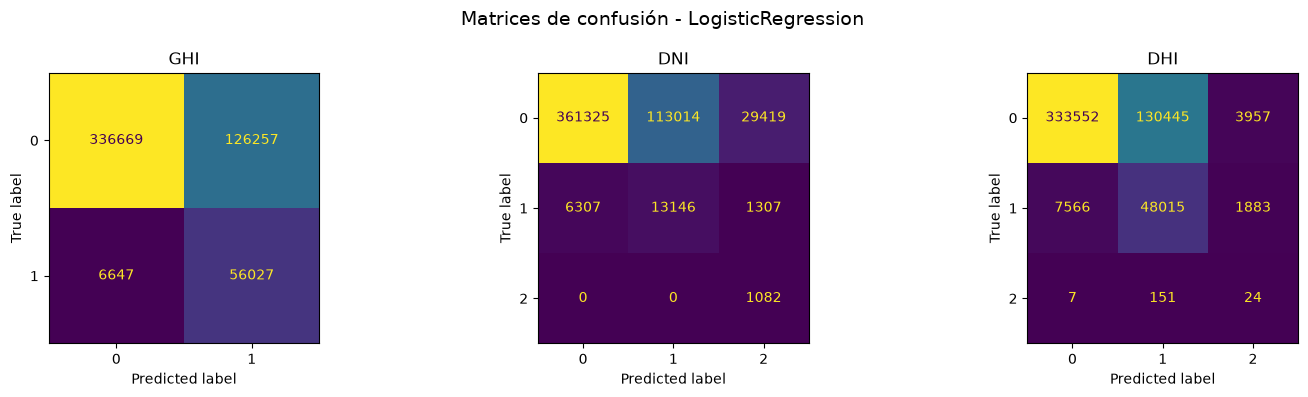

In [70]:
plot_confusion_matrices(
    test_df=df_test,
    predictions=lr_predictions,
    targets=TARGETS,
    model_name="LogisticRegression"
)

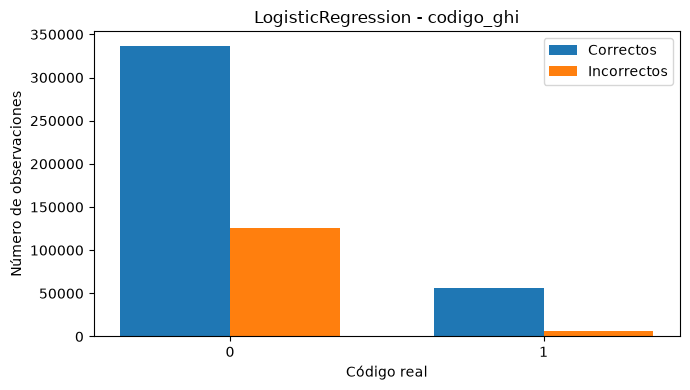

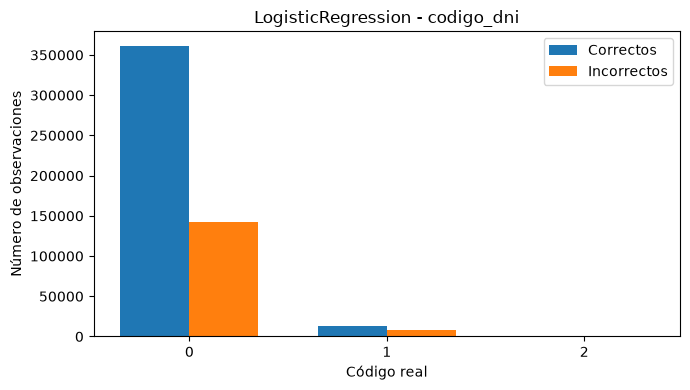

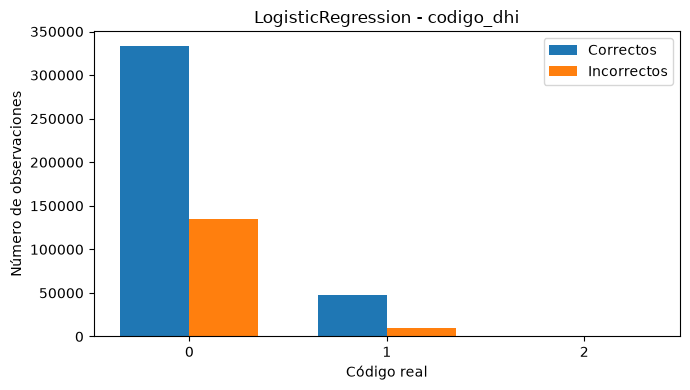

In [71]:
plot_correct_predictions_by_class(
    test_df=df_test,
    predictions=lr_predictions,
    targets=TARGETS,
    model_name="LogisticRegression"
)

In [74]:
results_df = lr_results.copy()

In [75]:
X_train_rf, X_test_rf, features_rf, scaler_rf = prepare_model_features(
    train_df=df_train,
    test_df=df_test,
    features=FEATURES,
    accepts_nan=False,
    scale=False
)

print(f"Número de features utilizadas: {len(features_rf)}")
print(features_rf)

print(f"\nNaN en train: {X_train_rf.isna().sum().sum()}")
print(f"NaN en test: {X_test_rf.isna().sum().sum()}")

Número de features utilizadas: 14
['mes_sin', 'mes_cos', 'dia', 'hora_sin', 'hora_cos', 'minuto', 'ghi', 'dni', 'dhi', 'error_balance_abs', 'elevacion_solar', 'periodo_solar', 'irr_null', 'var_meteo_imp']

NaN en train: 0
NaN en test: 0


In [76]:
from sklearn.ensemble import RandomForestClassifier

rf_models = {}
rf_predictions = {}

for target in TARGETS:

    model = RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_train_rf,
        df_train[target]
    )

    rf_models[target] = model

    rf_predictions[target] = model.predict(
        X_test_rf
    )

In [77]:
rf_results = evaluate_model_predictions(
    test_df=df_test,
    predictions=rf_predictions,
    targets=TARGETS,
    model_name="RandomForest",
    features=features_rf
)

display(rf_results)

,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted
0,RandomForest,codigo_ghi,14,0.5685,0.5643,0.8247
1,RandomForest,codigo_dni,14,0.4890,0.5511,0.9275
2,RandomForest,codigo_dhi,14,0.4505,0.5050,0.8470


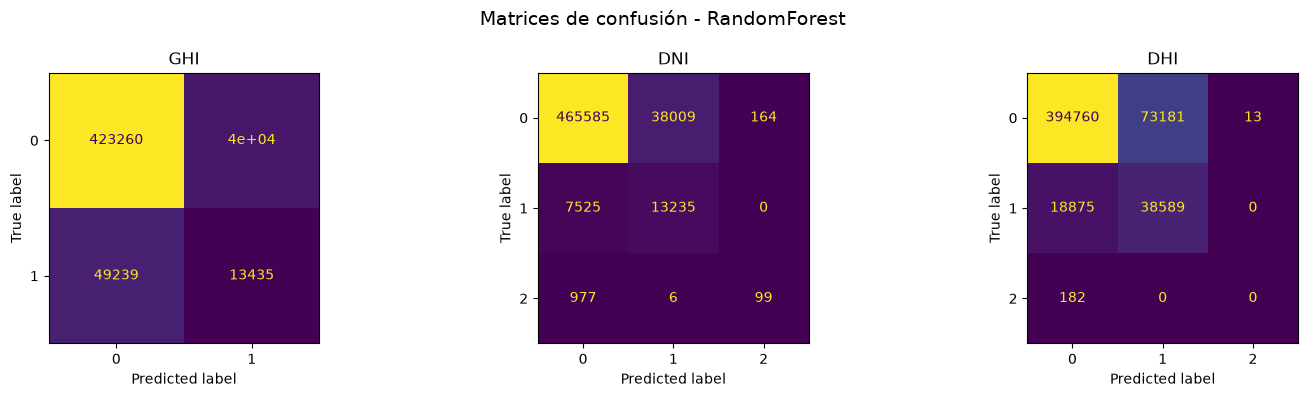

In [78]:
plot_confusion_matrices(
    test_df=df_test,
    predictions=rf_predictions,
    targets=TARGETS,
    model_name="RandomForest"
)

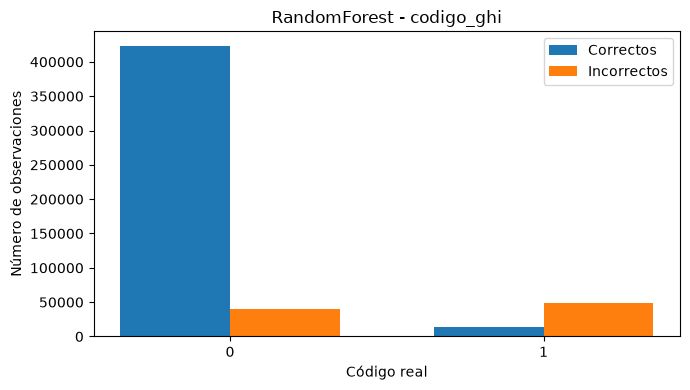

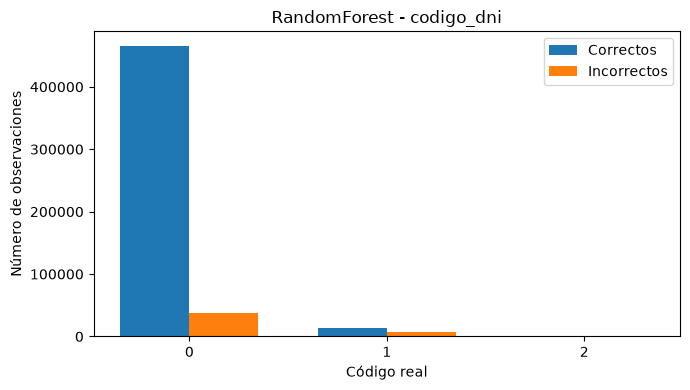

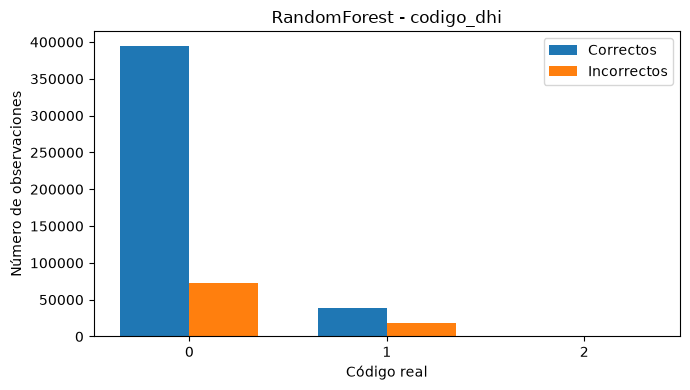

In [84]:
plot_correct_predictions_by_class(
    test_df=df_test,
    predictions=rf_predictions,
    targets=TARGETS,
    model_name="RandomForest"
)

In [79]:
results_df = pd.concat(
    [
        results_df,
        rf_results
    ],
    ignore_index=True
)

display(results_df)

,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted
0,LogisticRegression,codigo_ghi,14,0.6463,0.8106,0.7901
1,LogisticRegression,codigo_dni,14,0.3580,0.7835,0.8020
2,LogisticRegression,codigo_dhi,14,0.4131,0.5601,0.7786
3,RandomForest,codigo_ghi,14,0.5685,0.5643,0.8247
4,RandomForest,codigo_dni,14,0.4890,0.5511,0.9275
5,RandomForest,codigo_dhi,14,0.4505,0.5050,0.8470


In [ ]:
X_train_hgb, X_test_hgb, features_hgb, scaler_hgb = prepare_model_features(
    train_df=df_train,
    test_df=df_test,
    features=FEATURES,
    accepts_nan=True,
    scale=False
)

print(f"Número de features utilizadas: {len(features_hgb)}")
print(features_hgb)

print(f"\nNaN en train: {X_train_hgb.isna().sum().sum()}")
print(f"NaN en test: {X_test_hgb.isna().sum().sum()}")

Número de features utilizadas: 18
['mes_sin', 'mes_cos', 'dia', 'hora_sin', 'hora_cos', 'minuto', 'ghi', 'dni', 'dhi', 'error_balance_abs', 'elevacion_solar', 'periodo_solar', 'temperatura', 'velocidad_viento', 'humedad_relativa', 'direccion_viento_sin', 'direccion_viento_cos', 'var_meteo_imp']

NaN en train: 410655
NaN en test: 110108


In [81]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_models = {}
hgb_predictions = {}

for target in TARGETS:

    model = HistGradientBoostingClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    model.fit(
        X_train_hgb,
        df_train[target]
    )

    hgb_models[target] = model

    hgb_predictions[target] = model.predict(
        X_test_hgb
    )

In [82]:
hgb_results = evaluate_model_predictions(
    test_df=df_test,
    predictions=hgb_predictions,
    targets=TARGETS,
    model_name="HistGradientBoosting",
    features=features_hgb
)

display(hgb_results)

,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted
0,HistGradientBoosting,codigo_ghi,18,0.6158,0.6100,0.8428
1,HistGradientBoosting,codigo_dni,18,0.5347,0.6256,0.9409
2,HistGradientBoosting,codigo_dhi,18,0.4787,0.5559,0.8632


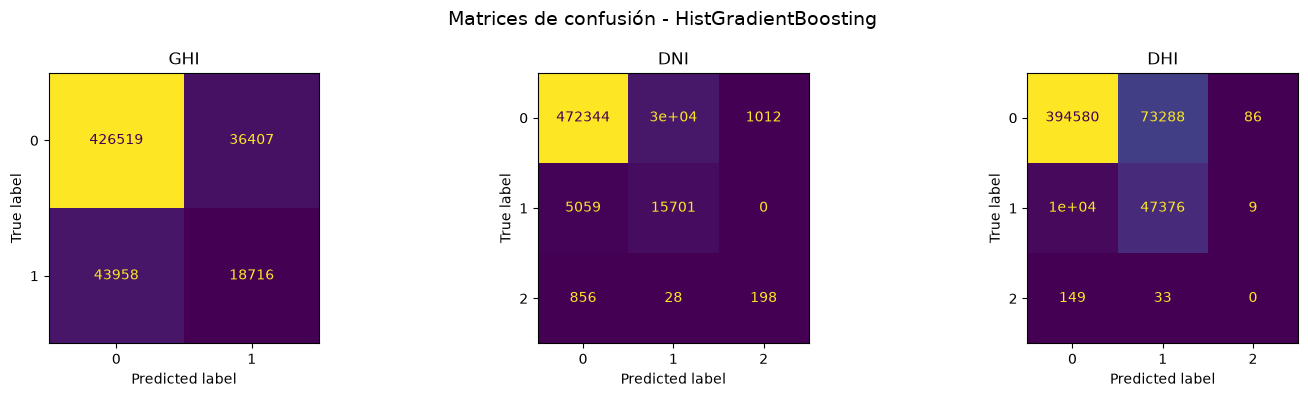

In [83]:
plot_confusion_matrices(
    test_df=df_test,
    predictions=hgb_predictions,
    targets=TARGETS,
    model_name="HistGradientBoosting"
)

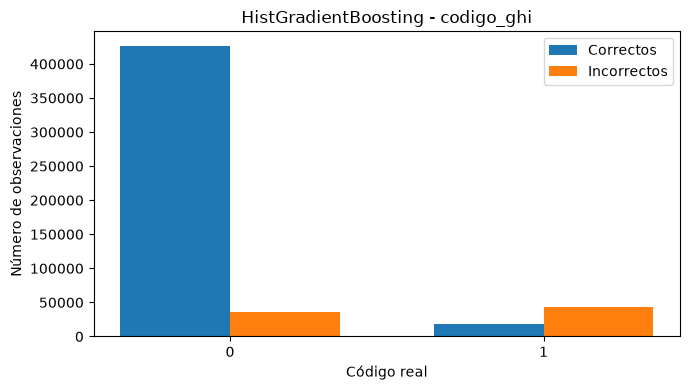

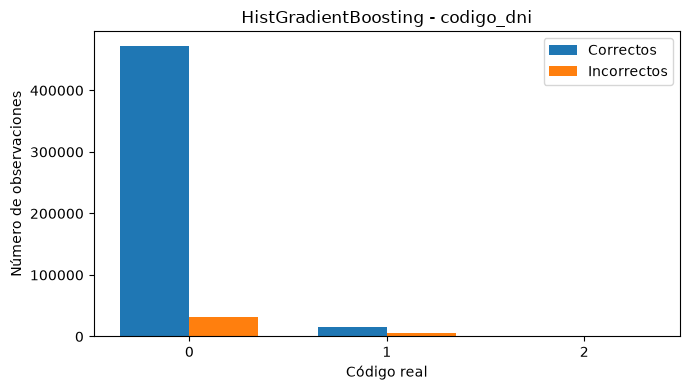

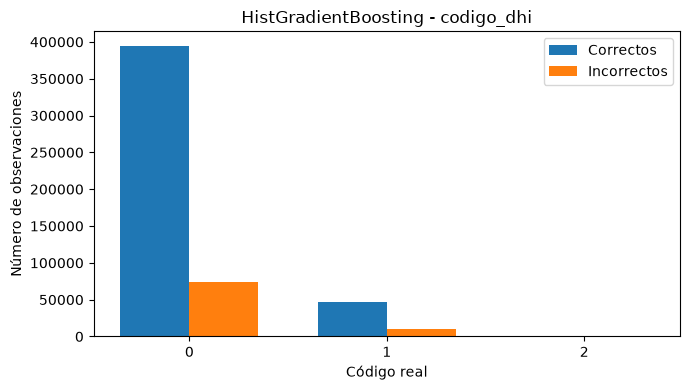

In [85]:
plot_correct_predictions_by_class(
    test_df=df_test,
    predictions=hgb_predictions,
    targets=TARGETS,
    model_name="HistGradientBoosting"
)

In [87]:
results_df = pd.concat(
    [
        results_df,
        hgb_results
    ],
    ignore_index=True
)

display(results_df)

,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted
0,LogisticRegression,codigo_ghi,14,0.6463,0.8106,0.7901
1,LogisticRegression,codigo_dni,14,0.3580,0.7835,0.8020
2,LogisticRegression,codigo_dhi,14,0.4131,0.5601,0.7786
3,RandomForest,codigo_ghi,14,0.5685,0.5643,0.8247
4,RandomForest,codigo_dni,14,0.4890,0.5511,0.9275
5,RandomForest,codigo_dhi,14,0.4505,0.5050,0.8470
6,HistGradientBoosting,codigo_ghi,18,0.6158,0.6100,0.8428
7,HistGradientBoosting,codigo_dni,18,0.5347,0.6256,0.9409
8,HistGradientBoosting,codigo_dhi,18,0.4787,0.5559,0.8632


In [88]:
comparison_table = create_model_comparison_table(
    results_df
)

display(comparison_table)

,model,n_features,codigo_ghi,codigo_dni,codigo_dhi
0,HistGradientBoosting,18,0.6158,0.5347,0.4787
1,LogisticRegression,14,0.6463,0.3580,0.4131
2,RandomForest,14,0.5685,0.4890,0.4505
